# XGBoost Model Building

**Project:** N₂O Emissions in Sub-Saharan Africa  
**Notebook objective:** Development, validation, tuning, diagnosis, and export of an XGBoost regression model for predicting N₂O flux.

This notebook documents the transition from exploratory data analysis to supervised model building. The modeling setup is based on the main observations from the EDA:

- The target variable is continuous, strongly right-skewed, and affected by extreme values.
- The dataset contains repeated observations that are grouped by `Event`.
- `Event` is treated as a grouping variable for validation and is excluded from the predictor set to reduce data leakage.
- Spatial coordinates, land-use information, meteorological variables, soil variables, fertilizer-related variables, and engineered temporal features are used as predictors.
- Model performance is evaluated on previously unseen events using a grouped train-test split.

# Table of Contents 
1. [ Modeling Strategy](#1-modeling-strategy)
2. [Imports and Configuration](#2-imports-and-configuration)
3. [Data Loading](#3-data-loading)
4. [Target and Feature Configuration](#4-target-and-feature-configuration)
5. [Feature Engineering](#5-feature-engineering)
6. [Train-Test Split by Event](#6-train-test-split-by-event)
7. [Preprocessing Pipeline](#7-preprocessing-pipeline)
8. [Baseline Model](#8-baseline-model)
9. [Initial XGBoost Model](#9-initial-xgboost-model)
10. [Hyperparameter Tuning with Grouped Cross-Validation](#10-hyperparameter-tuning-with-grouped-cross-validation)
11. [Final Model Evaluation](#11-final-model-evaluation)
12. [Error Analysis](#12-error-analysis)
13. [Feature Importance](#13-feature-importance)
14. [Diagnostic Plots](#14-diagnostic-plots)
15. [Save Model Artifacts](#15-save-model-artifacts)
16. [Optional Final Refit on All Data](#16-optional-final-refit-on-all-data)
17. [Summary and Next Steps](#17-summary-and-next-steps)

## 1. Modeling Strategy

The objective of the modeling step is to estimate the modeled N₂O flux from environmental, spatial, land-use, soil, and fertilizer-related predictors.

The modeling design follows four main decisions:

1. **Grouped validation:** Observations from the same `Event` are likely not independent. A random row-level split could therefore lead to overly optimistic performance estimates. For this reason, `Event` is used as the grouping variable for the holdout split and for cross-validation.
2. **Target transformation:** The EDA showed that N₂O flux is skewed and includes negative values. A shifted `log1p` transformation is tested for the tuned model. The shift is derived only from the training target to prevent leakage from the test set.
3. **Categorical encoding:** `Land use` is encoded with one-hot encoding. `Event` is not used as a direct model feature, because it mainly identifies measurement groups and could cause leakage.
4. **Robust evaluation:** Model quality is assessed using MAE, RMSE, R², median absolute error, bias, and residual summaries. MAE is especially relevant because the target contains extreme emission values.

## 2. Imports and Configuration

This section defines the required libraries, global plotting settings, warning behavior, and reproducibility settings used throughout the modeling workflow.

In [ ]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor


project_root = Path.cwd().parent
sys.path.append(str(project_root))

# from src.n2o_ml import io # import find_existing_path
from src.n2o_ml.io import find_existing_path, load_dataset,validate_required_columns
from src.n2o_ml.model_selection import split_by_group, build_group_kfold, summarize_split_distribution
from src.n2o_ml.preprocessing import make_one_hot_encoder, infer_feature_types, build_tabular_preprocessor, get_feature_type_lists
from src.n2o_ml.evaluation import regression_metrics, metrics_by_group
from src.n2o_ml.preprocessing import get_feature_type_lists
from src.n2o_ml.target_transform import ShiftedLogTargetTransformer
from src.n2o_ml.feature_engineering import add_n2o_domain_features
from src.n2o_ml.model_io import save_model_artifacts



sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ITER_SEARCH = 30
N_JOBS = -1


## 3. Data Loading

The dataset is loaded from a set of possible project paths. This makes the notebook executable from different working directories, such as the repository root, the `notebooks/` folder, or a temporary execution environment.

In [2]:
project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

DATA_PATH = find_existing_path(
    [
        project_root / "data" / "interim" / "n2o_ssa_landuse_aligned_combined.csv",
        project_root / "data" / "processed" / "n2o_ssa_landuse_aligned_combined.csv",
        Path("../data/interim/n2o_ssa_landuse_aligned_combined.csv"),
        Path("../data/processed/n2o_ssa_landuse_aligned_combined.csv"),
        Path("/mnt/data/n2o_ssa_landuse_aligned_combined.csv"),
    ],
    verbose=True,
)

df_raw = load_dataset(DATA_PATH, verbose=True)
df_raw.head()


Checking path: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Selected path: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Loaded dataset from: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\data\interim\n2o_ssa_landuse_aligned_combined.csv
Shape: 5,280 rows x 27 columns


,Event,Latitude,Longitude,Date/Time,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),...,VPD day m [kPa] (ERA5 reanalyses),PPPP day m [hPa] (ERA5 reanalyses),SWD day m [W/m**2] (ERA5 reanalyses),PPFD day m [µmol/m**2/s] (ERA5 reanalyses),Duration [days] (Since last precipitation even...),Duration [days] (Since last fertiliser applica...),Fert N dec adj exp [kg/ha] (Exponential decay model (k=0.05)),Transformation S (Modeled),Transformation C (Modeled),"N2O flux [µg/m**2/h] (From soil surface, Modeled)"
0,17AG-KILO-FLM,-3.1651,37.2354,2011-03-10,Forest,0,18.030489,23.117343,12.340325,0.067297,...,0.822001,819.566199,50.327010,101.660557,0,0,0.0,0.985770,-0.168101,0.490975
1,17AG-KILO-FLM,-3.1651,37.2354,2011-03-17,Forest,0,17.544443,20.264432,15.170010,8.913426,...,0.262965,818.716753,30.537043,61.684828,0,0,0.0,0.959059,-0.283206,0.000000
2,17AG-KILO-FLM,-3.1651,37.2354,2011-05-07,Forest,0,17.823329,20.757046,15.629188,0.358296,...,0.318645,821.894519,34.651581,69.996192,0,0,0.0,0.394356,-0.918958,-0.457550
3,17AG-KILO-COF,-3.2454,37.3195,2011-05-11,Forest,0,16.740588,19.703080,15.208345,1.130527,...,0.135640,835.511386,27.307722,55.161598,0,0,0.0,0.331418,-0.943484,59.965733
4,17AG-KILO-FOC,-3.1424,37.2423,2011-05-13,Forest,0,16.970899,20.616940,14.695255,0.460711,...,0.245536,816.466490,40.836629,82.489988,0,0,0.0,0.299363,-0.954139,47.169444


## 4. Target and Feature Configuration

This section defines the target variable, grouping column, date column, and required columns. The configuration is kept explicit so that later preprocessing and validation steps remain reproducible and easy to inspect.

In [3]:
TARGET_COLUMN = "N2O flux [µg/m**2/h] (From soil surface, Modeled)"
GROUP_COLUMN = "Event"
DATE_COLUMN = "Date/Time"
LAND_USE_COLUMN = "Land use"

REQUIRED_COLUMNS = [
    TARGET_COLUMN,
    GROUP_COLUMN,
    DATE_COLUMN,
    LAND_USE_COLUMN,
    "Latitude",
    "Longitude",
]


validate_required_columns(df_raw, REQUIRED_COLUMNS, verbose=True)

print(f"Target column: {TARGET_COLUMN}")
print(f"Group column : {GROUP_COLUMN}")
print(f"Date column  : {DATE_COLUMN}")
print(f"Land use     : {LAND_USE_COLUMN}")


All required columns are available.
Target column: N2O flux [µg/m**2/h] (From soil surface, Modeled)
Group column : Event
Date column  : Date/Time
Land use     : Land use


In [4]:
# Quick target overview before modeling.
df_raw[TARGET_COLUMN].describe()


count    5280.000000
mean       12.095709
std        20.839097
min       -21.149615
25%         1.896372
50%         5.142646
75%        13.045997
max       242.346036
Name: N2O flux [µg/m**2/h] (From soil surface, Modeled), dtype: float64

## 5. Feature Engineering

The feature engineering step converts the date column and creates additional temporal, cyclic, and interaction-based predictors. These features are derived from the EDA results and from process-related assumptions about N₂O emissions.

The raw date column is not used directly as a model feature. Instead, structured temporal information such as year, month, seasonality, and cyclic encodings is extracted.

In [5]:
df_model = add_n2o_domain_features(df_raw, date_column=DATE_COLUMN, verbose=True)
df_model.head()

Created 15 engineered features:
- year
- month
- day_of_year
- week_of_year
- month_sin
- month_cos
- day_of_year_sin
- day_of_year_cos
- season
- air_temp_range
- fert_n_per_day_since_application
- precip_recency_decay
- air_temp_x_topsoil_moisture
- fert_n_x_topsoil_moisture
- fert_n_x_air_temp


,Event,Latitude,Longitude,Date/Time,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),...,month_cos,day_of_year_sin,day_of_year_cos,season,air_temp_range,fert_n_per_day_since_application,precip_recency_decay,air_temp_x_topsoil_moisture,fert_n_x_topsoil_moisture,fert_n_x_air_temp
0,17AG-KILO-FLM,-3.1651,37.2354,2011-03-10,Forest,0,18.030489,23.117343,12.340325,0.067297,...,6.123234e-17,0.927238,0.374474,MAM,10.777018,0.0,1.0,5.381694,0.0,0.0
1,17AG-KILO-FLM,-3.1651,37.2354,2011-03-17,Forest,0,17.544443,20.264432,15.170010,8.913426,...,6.123234e-17,0.965507,0.260376,MAM,5.094422,0.0,1.0,6.845310,0.0,0.0
2,17AG-KILO-FLM,-3.1651,37.2354,2011-05-07,Forest,0,17.823329,20.757046,15.629188,0.358296,...,-8.660254e-01,0.817401,-0.576069,MAM,5.127858,0.0,1.0,5.868944,0.0,0.0
3,17AG-KILO-COF,-3.2454,37.3195,2011-05-11,Forest,0,16.740588,19.703080,15.208345,1.130527,...,-8.660254e-01,0.775859,-0.630907,MAM,4.494736,0.0,1.0,6.302345,0.0,0.0
4,17AG-KILO-FOC,-3.1424,37.2423,2011-05-13,Forest,0,16.970899,20.616940,14.695255,0.460711,...,-8.660254e-01,0.753698,-0.657221,MAM,5.921685,0.0,1.0,6.308256,0.0,0.0


In [6]:
# Define columns that must not be used as model input features.
drop_columns = [
    TARGET_COLUMN,
    DATE_COLUMN,
    GROUP_COLUMN,
]

# Check whether all required columns exist in the modeling dataframe.
missing_columns = [
    column for column in drop_columns
    if column not in df_model.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Check whether the target contains missing values before training.
if df_model[TARGET_COLUMN].isna().any():
    raise ValueError(
        "Target column contains missing values. Handle them before modeling."
    )

# Create feature matrix, target vector, and group vector.
X = df_model.drop(columns=drop_columns)
y = df_model[TARGET_COLUMN].copy()
groups = df_model[GROUP_COLUMN].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape        : {y.shape}")
print(f"Number of groups    : {groups.nunique()}")
print(f"Excluded columns    : {drop_columns}")

X.head()

Feature matrix shape: (5280, 39)
Target shape        : (5280,)
Number of groups    : 33
Excluded columns    : ['N2O flux [µg/m**2/h] (From soil surface, Modeled)', 'Date/Time', 'Event']


,Latitude,Longitude,Land use,Fert N [kg/ha] (Recorded at time of application),TTT day m [°C] (ERA5 reanalyses),TxTxTx day max [°C] (ERA5 reanalyses),TnTnTn day min [°C] (ERA5 reanalyses),Precip day total [mm/day] (ERA5 reanalyses),"Soil moisture [m**3/m**3] (Content at 0-7 cm depth, ERA5...)",Soil moisture [m**3/m**3] (ERA5 reanalyses),...,month_cos,day_of_year_sin,day_of_year_cos,season,air_temp_range,fert_n_per_day_since_application,precip_recency_decay,air_temp_x_topsoil_moisture,fert_n_x_topsoil_moisture,fert_n_x_air_temp
0,-3.1651,37.2354,Forest,0,18.030489,23.117343,12.340325,0.067297,0.298477,0.319371,...,6.123234e-17,0.927238,0.374474,MAM,10.777018,0.0,1.0,5.381694,0.0,0.0
1,-3.1651,37.2354,Forest,0,17.544443,20.264432,15.170010,8.913426,0.390170,0.365656,...,6.123234e-17,0.965507,0.260376,MAM,5.094422,0.0,1.0,6.845310,0.0,0.0
2,-3.1651,37.2354,Forest,0,17.823329,20.757046,15.629188,0.358296,0.329284,0.334593,...,-8.660254e-01,0.817401,-0.576069,MAM,5.127858,0.0,1.0,5.868944,0.0,0.0
3,-3.2454,37.3195,Forest,0,16.740588,19.703080,15.208345,1.130527,0.376471,0.336664,...,-8.660254e-01,0.775859,-0.630907,MAM,4.494736,0.0,1.0,6.302345,0.0,0.0
4,-3.1424,37.2423,Forest,0,16.970899,20.616940,14.695255,0.460711,0.371710,0.364974,...,-8.660254e-01,0.753698,-0.657221,MAM,5.921685,0.0,1.0,6.308256,0.0,0.0


## 6. Train-Test Split by Event

The holdout split is performed at event level. Complete events are assigned either to the training set or to the test set. This creates a stricter validation scenario than a random row-level split and better reflects the question of how well the model generalizes to unseen measurement events.

In [7]:
X_train, X_test, y_train, y_test, groups_train, groups_test = split_by_group(
    X,
    y,
    groups,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    verbose=True,
)

split_distribution = summarize_split_distribution(
    X_train,
    X_test,
    y_train,
    y_test,
    land_use_column=LAND_USE_COLUMN,
    verbose=True,
)

split_distribution

Train rows       : 4,907
Test rows        : 373
Train groups     : 26
Test groups      : 7
Group overlap    : 0
Train target mean: 12.1285
Test target mean : 11.6647
Created split distribution summary.


,split,land_use,count,mean,median,std,min,max
0,test,Cropland,90,25.060599,9.998872,39.502114,-12.719491,214.808427
1,test,Forest,161,11.983265,7.674300,14.670628,-7.100000,93.700000
2,test,Grassland,122,1.361995,1.038333,3.421183,-9.046667,17.496667
3,train,Cropland,3484,11.544503,5.445589,20.047043,-21.149615,242.346036
4,train,Forest,1320,13.848248,4.258871,22.241465,-11.501391,170.241240
5,train,Grassland,103,9.841595,3.873333,17.348942,-11.130000,118.179897


## 7. Preprocessing Pipeline

The preprocessing pipeline applies consistent transformations to numerical and categorical features. Numerical variables are imputed where necessary, while categorical variables are one-hot encoded.

Feature scaling is not required for XGBoost, because tree-based models are invariant to monotonic transformations of individual feature scales. The pipeline is still useful because it ensures that training, validation, and prediction use identical preprocessing steps.

In [8]:
numeric_features, categorical_features = get_feature_type_lists(X_train, verbose=True)
preprocessor = build_tabular_preprocessor(numeric_features, categorical_features, verbose=True)


Numeric features    : 37
Categorical features: 2
Categorical columns : ['Land use', 'season']
Using OneHotEncoder with sparse_output=False.
Tabular preprocessor created.
Numeric columns    : 37
Categorical columns: 2


## 8. Baseline Model

A baseline model is included as a reference point. It predicts a constant value based on the training target distribution. This makes it possible to judge whether XGBoost learns meaningful structure beyond a simple central tendency of the target.

In [9]:
# DummyRegressor expects a feature matrix. A zero-column placeholder is enough.
X_train_dummy = np.zeros((len(y_train), 1))
X_test_dummy = np.zeros((len(y_test), 1))

# baseline_model -> baseline_model_reg = DummyRegressor(strategy="median").fit(X_train_dummy, y_train)
baseline_model = DummyRegressor(strategy="median").fit(X_train_dummy, y_train)

baseline_metrics = regression_metrics(
    y_test, baseline_model.predict(X_test_dummy), prefix="baseline_", verbose=True
)

baseline_mae: 11.5324
baseline_rmse: 24.2531
baseline_r2: -0.0763
baseline_median_ae: 5.0067
baseline_bias_mean_residual: 6.4582


## 9. Initial XGBoost Model

The first XGBoost model is trained on the original target scale. This model provides an initial performance estimate and serves as a direct comparison against the baseline before target transformation and hyperparameter tuning.

In [10]:
# XGBRegressor hyperparameters can be tuned later using RandomizedSearchCV or GridSearchCV.
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    device= "cpu",#"cuda",
    # tree_method="hist",
)

# Build the initial pipeline with preprocessing and the XGBoost model.
xgb_initial = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ]
)


xgb_initial.fit(X_train, y_train)

initial_predictions = xgb_initial.predict(X_test)

# Evaluate the initial model performance using regression metrics.
initial_metrics = regression_metrics(
    y_test, initial_predictions, prefix="xgb_initial_", verbose=True
)

xgb_initial_mae: 11.8490
xgb_initial_rmse: 22.6899
xgb_initial_r2: 0.0580
xgb_initial_median_ae: 5.9075
xgb_initial_bias_mean_residual: -2.3125


## 10. Hyperparameter Tuning with Grouped Cross-Validation

The tuned model uses a shifted `log1p` transformation of the target. This transformation is intended to reduce the effect of skewness while still supporting negative target values through a training-set-based shift.

Hyperparameter tuning is performed with grouped cross-validation. The grouping structure is preserved during validation so that observations from the same `Event` are not split across training and validation folds.

In [11]:
log_transformer = ShiftedLogTargetTransformer(verbose=True)
y_train_log = log_transformer.fit_transform(y_train, verbose=True)

Initialized ShiftedLogTargetTransformer with margin=1e-06.
Training target minimum: -21.149615
Learned log shift      : 21.149616
Original target range   : -21.1496 to 242.3460
Transformed target range: 0.0000 to 5.5778


In [12]:
cv = build_group_kfold(groups_train, max_splits=5, verbose=True)

# Define hyperparameter search space for XGBoost model tuning.
param_distributions = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08, 0.10],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0.0, 0.001, 0.01, 0.1, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    "model__gamma": [0.0, 0.01, 0.1, 0.5, 1.0],
}

# Build the pipeline for hyperparameter search with preprocessing and the XGBoost model.
xgb_for_search = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ]
)

search = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=1,
    return_train_score=True,
)

search.fit(X_train, y_train_log, groups=groups_train)

print("Best CV score on transformed target scale:", search.best_score_)
print("Best parameters:")
for parameter, value in search.best_params_.items():
    print(f"- {parameter}: {value}")


Using GroupKFold with n_splits=5.
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV score on transformed target scale: -0.42813652487265735
Best parameters:
- model__subsample: 1.0
- model__reg_lambda: 2.0
- model__reg_alpha: 0.001
- model__n_estimators: 1200
- model__min_child_weight: 7
- model__max_depth: 2
- model__learning_rate: 0.1
- model__gamma: 0.5
- model__colsample_bytree: 0.9


In [13]:
cv_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_score")
    .loc[:, [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "std_train_score",
        "params",
    ]]
)

cv_results.head(10)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
3,1,-0.428137,0.077284,-0.278328,0.012513,"{'model__subsample': 1.0, 'model__reg_lambda':..."
23,2,-0.436206,0.063141,-0.298721,0.012295,"{'model__subsample': 1.0, 'model__reg_lambda':..."
24,3,-0.439591,0.066284,-0.292668,0.012910,"{'model__subsample': 0.9, 'model__reg_lambda':..."
4,4,-0.441759,0.081650,-0.242590,0.015229,"{'model__subsample': 0.9, 'model__reg_lambda':..."
8,5,-0.442717,0.079488,-0.269858,0.011418,"{'model__subsample': 0.8, 'model__reg_lambda':..."
18,6,-0.443196,0.070186,-0.279773,0.012440,"{'model__subsample': 0.6, 'model__reg_lambda':..."
14,7,-0.444153,0.077051,-0.268432,0.015517,"{'model__subsample': 0.9, 'model__reg_lambda':..."
13,8,-0.446350,0.076919,-0.264768,0.015045,"{'model__subsample': 0.7, 'model__reg_lambda':..."
16,9,-0.448795,0.087185,-0.251478,0.011622,"{'model__subsample': 0.8, 'model__reg_lambda':..."
7,10,-0.451005,0.076935,-0.262828,0.013651,"{'model__subsample': 0.6, 'model__reg_lambda':..."


## 11. Final Model Evaluation

The tuned model predicts on the transformed target scale. Predictions are inverse-transformed back to the original N₂O flux scale before evaluation.

The final evaluation is based on the event-level holdout test set. The reported metrics therefore describe performance on events that were not used during model fitting or hyperparameter selection.

In [14]:
best_xgb_log_model = search.best_estimator_

test_predictions_log = best_xgb_log_model.predict(X_test)

test_predictions = log_transformer.inverse_transform(test_predictions_log, verbose=True)


final_metrics = regression_metrics(
    y_test,
    test_predictions,
    prefix="xgb_tuned_log_",
    verbose=True,
)

# Remove model-specific prefixes so all metric dictionaries share the same index
baseline_metrics_clean = {
    key.replace("baseline_", ""): value
    for key, value in baseline_metrics.items()
}

initial_metrics_clean = {
    key.replace("xgb_initial_", ""): value
    for key, value in initial_metrics.items()
}

final_metrics_clean = {
    key.replace("xgb_tuned_log_", ""): value
    for key, value in final_metrics.items()
}

# Build a clean comparison table with metrics as rows and models as columns
metrics_table = pd.DataFrame(
    {
        "baseline_median": baseline_metrics_clean,
        "xgb_initial_raw": initial_metrics_clean,
        "xgb_tuned_shifted_log": final_metrics_clean,
    }
)

# Keep metrics in a clear and consistent order
metrics_table = metrics_table.loc[
    [
        "mae",
        "rmse",
        "r2",
        "median_ae",
        "bias_mean_residual",
    ]
]

metrics_table

Inverse-transformed range: -1.0127 to 32.8762
xgb_tuned_log_mae: 9.8400
xgb_tuned_log_rmse: 21.2498
xgb_tuned_log_r2: 0.1737
xgb_tuned_log_median_ae: 4.3456
xgb_tuned_log_bias_mean_residual: 2.9043


,baseline_median,xgb_initial_raw,xgb_tuned_shifted_log
mae,11.532382,11.848976,9.840036
rmse,24.253118,22.689891,21.249836
r2,-0.076319,0.057957,0.173739
median_ae,5.006693,5.907488,4.345650
bias_mean_residual,6.458232,-2.312531,2.904330


In [15]:
predictions_df = X_test[[LAND_USE_COLUMN]].copy()
predictions_df[GROUP_COLUMN] = groups_test.values
predictions_df["y_true"] = y_test.values
predictions_df["y_pred"] = test_predictions
predictions_df["residual"] = predictions_df["y_true"] - predictions_df["y_pred"]
predictions_df["absolute_error"] = predictions_df["residual"].abs()

predictions_df.head()


,Land use,Event,y_true,y_pred,residual,absolute_error
374,Forest,18IW-CHESP-TEA,9.373760,23.370305,-13.996545,13.996545
396,Forest,18IW-CHESP-TEA,23.178716,12.592997,10.585719,10.585719
399,Forest,18IW-CHESP-TEA,2.564192,10.537241,-7.973049,7.973049
411,Forest,18IW-CHESP-TEA,0.000000,8.846879,-8.846879,8.846879
432,Forest,18IW-CHESP-TEA,6.229523,16.987550,-10.758027,10.758027


## 12. Error Analysis

This section examines whether prediction errors vary systematically across land-use classes, events, and target-intensity ranges. The goal is to identify model weaknesses that are not visible from global metrics alone.

In [16]:
land_use_error = metrics_by_group(
    predictions_df,
    group_column=LAND_USE_COLUMN,
    min_count=1,
    verbose=True,
)

land_use_error


Calculated metrics for 3 groups from column: Land use


,Land use,count,mae,rmse,r2,median_ae,bias_mean_residual
0,Cropland,90,23.306308,39.270497,0.000588,12.367061,9.583985
1,Forest,161,7.840262,13.175051,0.188454,5.019895,2.242349
2,Grassland,122,2.544948,3.719740,-0.191920,1.687282,-1.149688


In [17]:
event_error = metrics_by_group(
    predictions_df,
    group_column=GROUP_COLUMN,
    min_count=5,
    verbose=True,
)

event_error.head(20)


Calculated metrics for 7 groups from column: Event


,Event,count,mae,rmse,r2,median_ae,bias_mean_residual
0,23ML-MACH,90,23.306308,39.270497,0.000588,12.367061,9.583985
1,25CA-SOR4D_DAF,45,12.602846,20.870159,-0.060088,7.399234,5.851889
2,18IW-CHESP-TEA,42,9.272324,12.356249,0.201316,8.077213,3.025313
3,18IW-KAP-EUCH,33,4.729025,5.747160,-0.131734,4.151822,-1.919420
4,22MB-Jardin,41,3.650211,4.536908,-0.562206,2.979352,0.828317
5,20SW-LUMO,60,2.548556,3.829444,-0.064391,1.679430,-0.914988
6,20SW-B-Mak,62,2.541457,3.610402,-0.379553,1.711942,-1.376817


### Error Analysis Across Target Quantiles

To evaluate whether the model performs differently for low and high N₂O flux values, the true target values are divided into four quantile-based groups.

Unlike fixed-width bins, quantile bins contain approximately the same number of observations. This makes the error metrics easier to compare across different target ranges, especially because the N₂O flux distribution is strongly skewed.

The grouped metrics show whether prediction errors increase for higher emission values and whether the model performs consistently across the full target distribution.

In [18]:
# Create four target-value groups with approximately equal numbers of observations.
predictions_df["target_quantile_bin"] = pd.qcut(
    predictions_df["y_true"],
    q=4,
    duplicates="drop",
)

# Display the number of observations in each quantile bin.
print(
    predictions_df["target_quantile_bin"]
    .value_counts()
    .sort_index()
)

# Calculate regression metrics separately for each target-value range.
quantile_error = metrics_by_group(
    predictions_df,
    group_column="target_quantile_bin",
    min_count=1,
    verbose=True,
)

quantile_error

target_quantile_bin
(-12.719999999999999, 0.563]    94
(0.563, 3.873]                  93
(3.873, 12.77]                  93
(12.77, 214.808]                93
Name: count, dtype: int64
Calculated metrics for 4 groups from column: target_quantile_bin


d:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\src\n2o_ml\evaluation.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, group_df in dataframe.groupby(group_column, dropna=False):


,target_quantile_bin,count,mae,rmse,r2,median_ae,bias_mean_residual
0,"(12.77, 214.808]",93,23.896684,40.472166,-0.401500,12.643279,23.146559
1,"(-12.719999999999999, 0.563]",94,6.785005,9.956765,-12.858665,4.135664,-6.715158
2,"(3.873, 12.77]",93,5.113727,6.404451,-4.821517,3.965902,-1.420246
3,"(0.563, 3.873]",93,3.597579,5.644575,-38.848041,1.679797,-3.290401


## 13. Feature Importance

Feature importance is extracted from the fitted XGBoost model after preprocessing. One-hot encoded categorical variables are represented by their expanded feature names.

The importance values provide an initial indication of which predictors contribute most strongly to the fitted model. They are interpreted as model-specific importance scores and not as causal effects.

In [19]:
from src.n2o_ml.xgboost_io import extract_xgb_importance

importance_df = extract_xgb_importance(
    best_xgb_log_model,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    importance_type="gain",
    verbose=True,
)

importance_df.head(30)


Extracted 44 transformed feature names.
Extracted importance for 44 features.


,feature,importance
0,air_temp_range,11.357521
1,Latitude,10.057660
2,year,9.990196
3,Longitude,7.080940
4,month,5.647122
5,Soil moisture [m**3/m**3] (ERA5 reanalyses),5.642098
6,Duration [days] (Since last precipitation even...,5.389771
7,Cloud cov [%] (ERA5 reanalyses),5.214423
8,TTT day m [°C] (ERA5 reanalyses),4.508403
9,TxTxTx day max [°C] (ERA5 reanalyses),3.907160


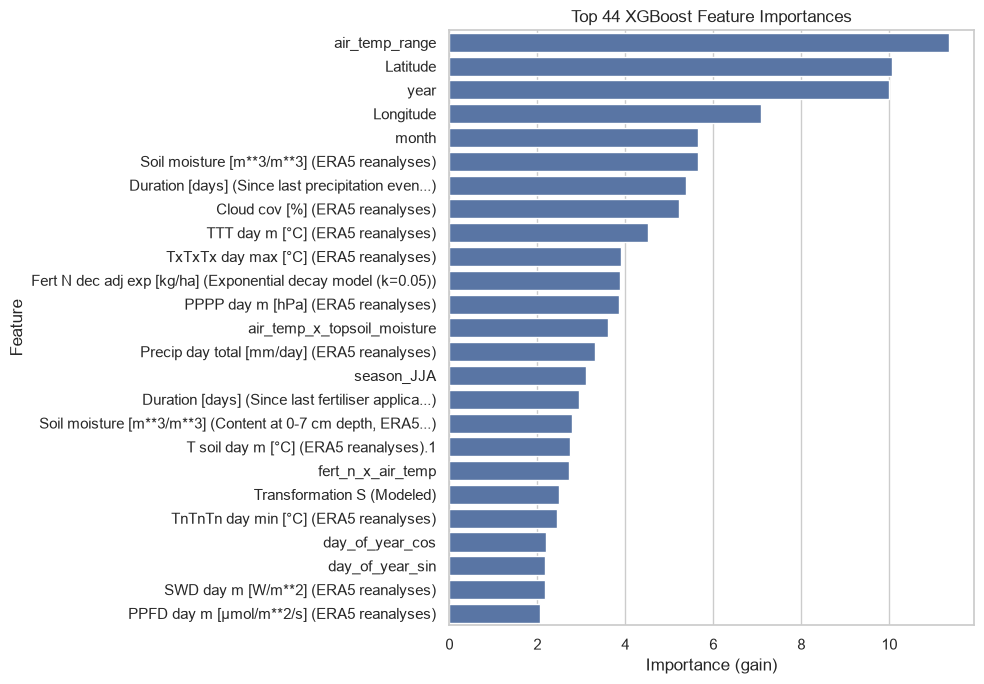

In [20]:
top_n = 25

plt.figure(figsize=(10, max(5, top_n * 0.28)))
sns.barplot(data= importance_df.head(top_n).sort_values("importance", ascending=False), x="importance", y="feature")
plt.xlabel("Importance (gain)")
plt.ylabel("Feature")
plt.title(f"Top {len(importance_df)} XGBoost Feature Importances")
plt.tight_layout()
plt.show()


## 14. Diagnostic Plots

The diagnostic plots visualize prediction quality and residual behavior on the holdout test set. They are used to inspect systematic deviations, heteroscedasticity, and the model behavior for high-emission observations.

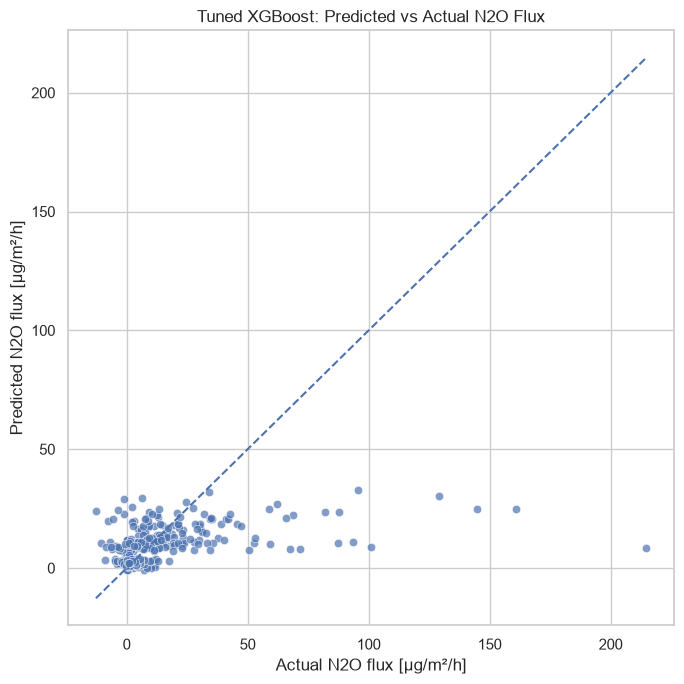

In [21]:
# Plot predicted values against actual values.
y_true_array = np.asarray(y_test, dtype=float)
y_pred_array = np.asarray(test_predictions, dtype=float)

axis_min = min(y_true_array.min(), y_pred_array.min())
axis_max = max(y_true_array.max(), y_pred_array.max())


plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_true_array, y=y_pred_array, alpha=0.7)
plt.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--")
plt.xlabel("Actual N2O flux [µg/m²/h]")
plt.ylabel("Predicted N2O flux [µg/m²/h]")
plt.title("Tuned XGBoost: Predicted vs Actual N2O Flux")
plt.tight_layout()
plt.show()



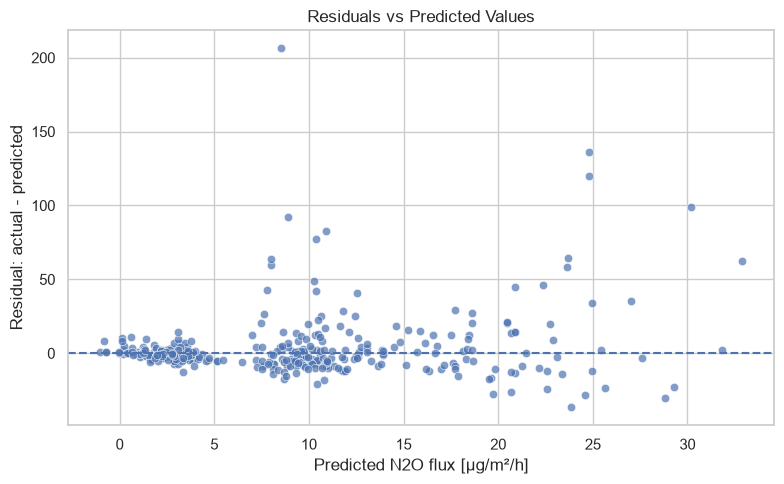

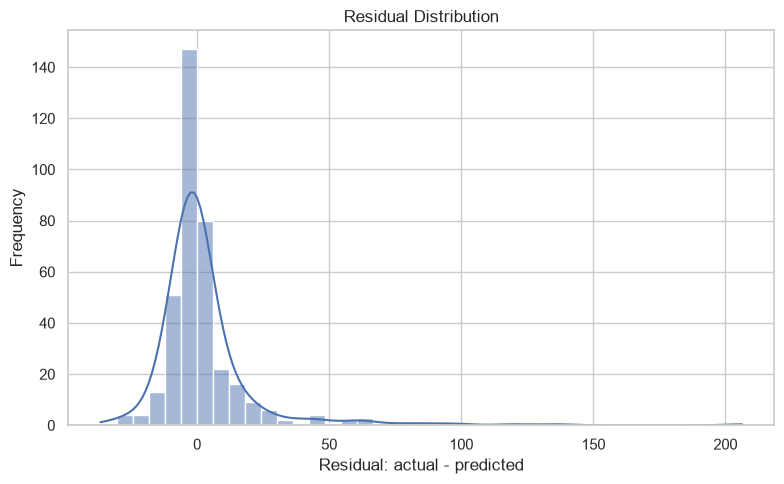

In [22]:
residuals = y_true_array - y_pred_array

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_array, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted N2O flux [µg/m²/h]")
plt.ylabel("Residual: actual - predicted")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.xlabel("Residual: actual - predicted")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()




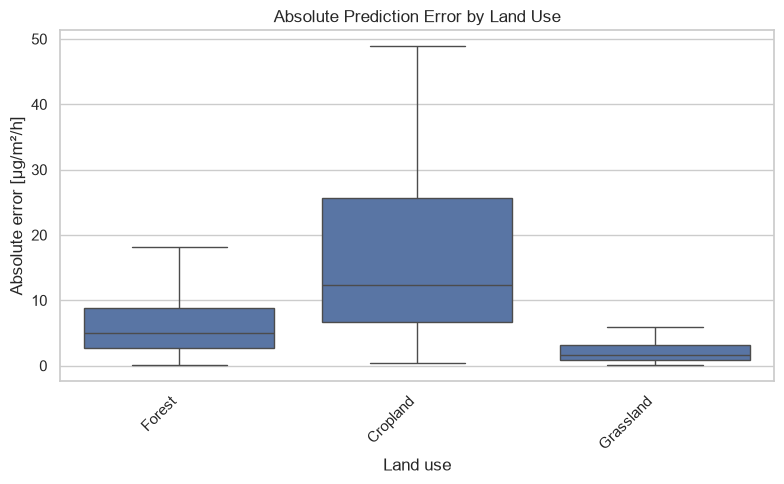

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=predictions_df,
    x=LAND_USE_COLUMN,
    y="absolute_error",
    showfliers=False,
)
plt.xlabel("Land use")
plt.ylabel("Absolute error [µg/m²/h]")
plt.title("Absolute Prediction Error by Land Use")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
# Optional: inspect predictions for the largest absolute errors.
predictions_df.sort_values("absolute_error", ascending=False).head(20)


,Land use,Event,y_true,y_pred,residual,absolute_error,target_quantile_bin
1590,Cropland,23ML-MACH,214.808427,8.550841,206.257585,206.257585,"(12.77, 214.808]"
1521,Cropland,23ML-MACH,160.845870,24.788117,136.057753,136.057753,"(12.77, 214.808]"
1523,Cropland,23ML-MACH,144.568865,24.788117,119.780748,119.780748,"(12.77, 214.808]"
1500,Cropland,23ML-MACH,129.037121,30.192689,98.844432,98.844432,"(12.77, 214.808]"
1557,Cropland,23ML-MACH,101.103017,8.882491,92.220527,92.220527,"(12.77, 214.808]"
1051,Forest,25CA-SOR4D_DAF,93.700000,10.884772,82.815228,82.815228,"(12.77, 214.808]"
1022,Forest,25CA-SOR4D_DAF,87.500000,10.364155,77.135845,77.135845,"(12.77, 214.808]"
1507,Cropland,23ML-MACH,87.939558,23.662692,64.276866,64.276866,"(12.77, 214.808]"
1565,Cropland,23ML-MACH,71.661532,8.015339,63.646192,63.646192,"(12.77, 214.808]"
1496,Cropland,23ML-MACH,95.477820,32.876228,62.601592,62.601592,"(12.77, 214.808]"


## 15. Save Model Artifacts

The fitted model and all relevant evaluation artifacts are exported for later reuse. The saved outputs include:

- the fitted preprocessing and XGBoost pipeline,
- the target shift required for inverse transformation,
- feature lists,
- evaluation metrics,
- holdout predictions,
- feature-importance values.

In [25]:
best_xgb_log_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['Latitude','Longitude','Land use',...,'air_temp_x_topsoil_moisture', 'fert_n_x_topsoil_moisture','fert_n_x_air_temp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` wil

In [30]:
ARTIFACT_DIR = project_root / "models" / "xgboost_n2o"

artifact_metadata = {
    "model_type": "XGBRegressor",
    "target_column": TARGET_COLUMN,
    "group_column": GROUP_COLUMN,
    "date_column": DATE_COLUMN,
    "land_use_column": LAND_USE_COLUMN,
    "target_transformation": {
        "name": "shifted_log1p",
        "shift": log_transformer.shift_,
    },
    "validation_strategy": "grouped_holdout",
}

artifact_tables = {
    "metrics": metrics_table,
    "holdout_predictions": predictions_df,
    "feature_importance": importance_df,
}

artifact_feature_groups = {
    "numeric": numeric_features,
    "categorical": categorical_features,
}

saved_paths = save_model_artifacts(
    model=best_xgb_log_model,
    output_dir=ARTIFACT_DIR,
    model_name="xgboost_n2o",
    tables=artifact_tables,
    metadata=artifact_metadata,
    feature_groups=artifact_feature_groups,
    table_index=False,
    overwrite=True,
    verbose=True,
)

saved_paths

Saved model artifacts:
- model: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_model.joblib
- metrics: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_metrics.csv
- holdout_predictions: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_holdout_predictions.csv
- feature_importance: D:\Programming\general_projects\n2o_emission_africa\n2o-emissions-africa-ml\models\xgboost_n2o\xgboost_n2o_feature_importance.csv


{'model': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_model.joblib'),
 'metrics': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_metrics.csv'),
 'holdout_predictions': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_holdout_predictions.csv'),
 'feature_importance': WindowsPath('d:/Programming/general_projects/n2o_emission_africa/n2o-emissions-africa-ml/models/xgboost_n2o/xgboost_n2o_feature_importance.csv')}

## 16. Optional Final Refit on All Data

The previous model represents the honest evaluation model, because it is trained only on the training split and evaluated on unseen events. After the holdout performance has been documented, a production-style model can optionally be refitted on all available observations using the selected hyperparameters.

This optional refit is not used to revise the holdout metrics. It only creates a final model artifact trained on the maximum available amount of data.

In [ ]:
# Optional production-style refit on all available data.
# This model should not be used for holdout evaluation, because it has seen all observations.

REFIT_ON_ALL_DATA = False

if REFIT_ON_ALL_DATA:
    full_target_shift = calculate_log_shift(y, verbose=True)
    y_full_log = transform_target_log1p_shifted(y, shift=full_target_shift, verbose=True)

    final_model_all_data = clone(best_xgb_log_model)
    final_model_all_data.fit(X, y_full_log)

    final_artifact_dir = project_root / "models" / "xgboost_n2o_final_all_data"
    final_artifact_dir.mkdir(parents=True, exist_ok=True)

    final_bundle = {
        "model": final_model_all_data,
        "target_shift": full_target_shift,
        "target_transform": "shifted_log1p",
        "numeric_features": list(numeric_features),
        "categorical_features": list(categorical_features),
        "target_column": TARGET_COLUMN,
        "group_column": GROUP_COLUMN,
        "date_column": DATE_COLUMN,
        "land_use_column": LAND_USE_COLUMN,
    }

    final_model_path = final_artifact_dir / "xgboost_n2o_final_all_data.joblib"
    joblib.dump(final_bundle, final_model_path)

    print(f"Saved final all-data model to: {final_model_path.resolve()}")
else:
    print("Skipped final refit on all data. Set REFIT_ON_ALL_DATA = True to run it.")


## 17. Summary and Next Steps

This section is reserved for the final interpretation after the notebook has been executed.

The modeling summary should document:

1. the baseline performance compared with the initial XGBoost model,
2. the tuned XGBoost performance on unseen events,
3. the effect of the shifted-log target transformation on MAE, RMSE, and residual behavior,
4. the most relevant predictors according to gain-based feature importance,
5. systematic error differences across land-use classes or events,
6. the model behavior for high-emission observations.

Potential next steps include:

- comparison with additional model families such as Random Forest, HistGradientBoosting, and ElasticNet,
- evaluation with leave-one-event-out cross-validation,
- testing a reduced feature set without model-derived variables such as `Transformation S` and `Transformation C`,
- SHAP-based interpretation for a more detailed explanation of model behavior,
- creation of a compact model card for the project README.